In [113]:
import MDAnalysis as mda
from MDAnalysis.transformations import unwrap, center_in_box
import os
import numpy as np
import freud
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

In [114]:
lipids = 4000

In [115]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"
top_file = os.path.join(dir, "tests/bilayer.data")
traj_file = os.path.join(dir, "tests/bilayer.lammpstrj")

In [116]:
u = mda.Universe(top_file, format="DATA", atom_style = "id resid type charge x y z")
u.load_new(traj_file, format="LAMMPSDUMP", dt=0.01)

<Universe with 176081 atoms>

In [117]:
lipid_atoms = u.select_atoms(f"resid 1:{lipids}")

transforms = unwrap(lipid_atoms)
u.trajectory.add_transformations(transforms)

In [118]:
nematic = freud.order.Nematic()

In [119]:
def neamtic_order(universe,gro=False):

    s_values = np.zeros(len(universe.trajectory))
    directors = np.zeros((len(universe.trajectory), 3))

    lipid_res = universe.residues[:lipids]
    if gro:
        lipid_res = universe.select_atoms("resname POPC*").residues

    for frame_id, frame in enumerate(universe.trajectory):


        orientations = np.zeros((len(lipid_res), 3))

        for mol_id, mol in enumerate(lipid_res):

            positions = mol.atoms.positions
            orientation_long = (positions[7] + positions[11])/2 - positions[0]
            orientations[mol_id] = orientation_long/np.linalg.norm(orientation_long)

        nematic.compute(orientations)

        s_values[frame_id] = nematic.order
        directors[frame_id] = nematic.director

    return s_values, directors

In [120]:
s_values, directors = neamtic_order(u)

In [121]:
def grids_per_frame(universe, N = 16, directors = directors):

    n_frames = len(universe.trajectory)
    lipid_res = universe.residues[:lipids]

    grids = np.zeros((n_frames, N, N))

    for frame_id, frame in enumerate(universe.trajectory):

        box_x, box_y = universe.dimensions[0], universe.dimensions[1]

        coms = [res.atoms.center_of_mass() for res in lipid_res]
        x = [t[0] for t in coms]
        y = [t[1] for t in coms]

        director = directors[frame_id]
        z = [(t @ director) for t in coms]
        z = z - np.mean(z)

        h_grid, x_edges, y_edges, bin_numbers = binned_statistic_2d(x, y, z, statistic="mean", bins=[N,N], range=[[0,box_x], [0,box_y]])

        grids[frame_id] = h_grid

    return grids

In [122]:
def power_spectrum(universe, N = 16, directors = directors):

    n_frames = len(universe.trajectory)
    grids = grids_per_frame(u)
    h_qs = [np.fft.fft2(grid) for grid in grids]

    avg_power_spectrum = np.zeros((N,N))

    for frame_id in range(n_frames):

        power_spectrum = np.abs(h_qs[frame_id])**2
        avg_power_spectrum += power_spectrum

    avg_power_spectrum = avg_power_spectrum/n_frames

    box_x, box_y = universe.dimensions[0], universe.dimensions[1]
    avg_power_spectrum = np.fft.fftshift(avg_power_spectrum)* (box_x*box_y) 

    return avg_power_spectrum

In [123]:
a = power_spectrum(u)

In [124]:
def q_norm(universe, N = 16):

    box_x, box_y = universe.dimensions[0], universe.dimensions[1]
    dx, dy = box_x/N, box_y/N

    qx, qy = np.fft.fftshift(np.fft.fftfreq(N, dx)), np.fft.fftshift(np.fft.fftfreq(N, dy))
    QX, QY = np.meshgrid(qx, qy)

    Q_norm = np.sqrt(QX**2 + QY**2)

    return Q_norm


In [125]:
qs = q_norm(u)

In [126]:
def radial_profile(data, q_norm_grid, n_bins):

    q_max = np.max(q_norm_grid)
    q_bins = np.linspace(0, q_max, n_bins)
    q_centers = (q_bins[:-1] + q_bins[1:]) / 2

    radial_mean = []

    for i in range(len(q_bins) - 1):

        mask = (q_norm_grid >= q_bins[i]) & (q_norm_grid < q_bins[i+1])

        values = data[mask]

        if len(values) > 0:
            radial_mean.append(np.mean(values))
        else:
            radial_mean.append(np.nan)

    return q_centers, np.array(radial_mean)

In [136]:
q_radial, power_radial = radial_profile(a, qs, 50)

In [137]:
print(power_radial)

[1.22125869e+03            nan            nan            nan
 3.31202660e+06            nan 1.09533088e+06            nan
 9.55582328e+05 5.95909692e+05            nan            nan
 3.26607077e+05 3.00444729e+05            nan 1.64147902e+05
            nan 2.21159856e+05 7.14644086e+04 7.91920471e+04
            nan 1.13212398e+05 6.11110723e+04 6.45331285e+04
 5.00872056e+04 8.48006455e+04 4.53900605e+04 4.15338578e+04
            nan 3.64048785e+04 6.49987604e+04 3.30246925e+04
 3.37221100e+04 4.10079373e+04 3.95161294e+04 3.05463811e+04
 2.83430150e+04 3.29622326e+04 3.75821720e+04 2.85853213e+04
 4.49235889e+04            nan 3.01816178e+04 2.49068176e+04
            nan            nan 2.50834099e+04            nan
            nan]


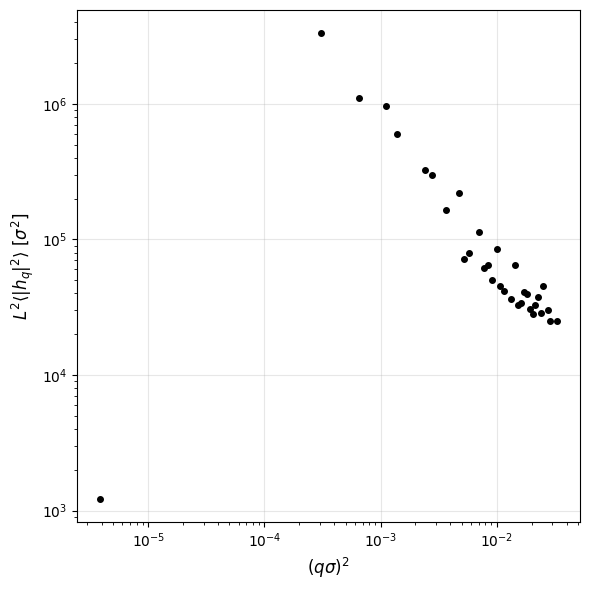

In [138]:
plt.figure(figsize=(6,6))

plt.loglog(q_radial**2, power_radial, 'o', color='black', markersize=4)

plt.xlabel(r'$(q\sigma)^2$', fontsize=12)
plt.ylabel(r'$L^2 \langle |h_q|^2 \rangle$ $[\sigma^2]$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()